In [3]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from edgar import set_identity, Company
import sys

# This moves up two levels from 'research/notebooks' to 'stock-analysis'
path_to_root = os.path.abspath(os.path.join('..', '..'))

if path_to_root not in sys.path:
    sys.path.append(path_to_root)

from research.PyCode.sentiment_analysis import get_openai_sentiment

# 1. Notebook Configuration
plt.style.use('ggplot')
set_identity('Honza Tous honza.tous@gmail.com')

In [30]:
import pandas as pd
from edgar import Company
import re
from tqdm import tqdm

# List of Top 10 Companies (by approx market cap)
tickers = ["AAPL", "MSFT", "NVDA", "GOOGL", "AMZN", "META", "TSLA", "BRK-B", "LLY", "AVGO"]
num_quarters = 20

raw_data = []

print(f"Starting extraction for {len(tickers)} companies...")

# --- Outer Loop: Iterate through Companies ---
for ticker in tickers:
    print(f"\nProcessing {ticker}...")
    
    try:
        company = Company(ticker)
        filings = company.get_filings(form="10-Q")
        
        # Check if we have enough filings
        if not filings:
            print(f"No 10-Q filings found for {ticker}")
            continue
            
        meta_df = filings.to_pandas()
        target_indices = meta_df.head(num_quarters).index
        
        # --- Inner Loop: Iterate through Quarters ---
        # We use tqdm here to show progress for this specific company
        for idx in tqdm(target_indices, desc=f"Extracting {ticker}", leave=False):
            filing = filings[int(idx)]
            
            # 1. Get the full document as Markdown text
            full_text = filing.markdown()
            
            # 2. Use Regex to find the text between Item 2 and Item 3
            # (Using your robust regex pattern)
            pattern = re.compile(
                r'(Item\s+2[.:]?\s+Management.*?)(?=Item\s+3[.:]?)', 
                re.IGNORECASE | re.DOTALL
            )
            
            matches = pattern.findall(full_text)
            
            mda_text = ""
            if matches:
                # Take the longest match (avoids Table of Contents snippets)
                mda_text = max(matches, key=len)
            
            # Financials (standard lookup)
            tenq = filing.obj()
            revenue = None
            net_income = None
            
            # Safe access to financials
            if tenq and hasattr(tenq, 'financials') and tenq.financials:
                revenue = tenq.financials.get_revenue()
                net_income = tenq.financials.get_net_income()

            # Append to list with the TICKER column
            raw_data.append({
                'ticker': ticker,  # <--- Added Ticker Column
                'date': filing.filing_date,
                'revenue': revenue,
                'net_income': net_income,
                'mda_text': mda_text.strip()
            })
            
    except Exception as e:
        print(f"Error processing {ticker}: {e}")
        continue

# Create final flat DataFrame
df_raw = pd.DataFrame(raw_data)

print("\n--- Extraction Complete ---")
print(f"Total rows collected: {len(df_raw)}")
print(df_raw[['ticker', 'date', 'revenue']].head())

# Optional: Check distribution
print("\nFilings per company:")
print(df_raw['ticker'].value_counts())

Starting extraction for 10 companies...

Processing AAPL...



Processing MSFT...



Processing NVDA...



Processing GOOGL...



Processing AMZN...


...


Processing TSLA...



Processing BRK-B...



Processing LLY...



Processing AVGO...



--- Extraction Complete ---
Total rows collected: 200
  ticker        date  revenue
0   AAPL  2026-01-30      NaN
1   AAPL  2025-08-01      NaN
2   AAPL  2025-05-02      NaN
3   AAPL  2025-01-31      NaN
4   AAPL  2024-08-02      NaN

Filings per company:
ticker
AAPL     20
MSFT     20
NVDA     20
GOOGL    20
AMZN     20
META     20
TSLA     20
BRK-B    20
LLY      20
AVGO     20
Name: count, dtype: int64


In [36]:
import openpyxl
df_raw.to_excel('companies_data.xlsx', index=False)

In [37]:
print(df_raw.columns)

Index(['ticker', 'date', 'revenue', 'net_income', 'mda_text'], dtype='object')


In [38]:
# Check missing values per ticker
missing_summary = df_raw.groupby('ticker').apply(lambda x: x.isna().sum())

print("Missing values count per company:")
display(missing_summary)

# Calculate the percentage of missing data to see the "health" of your dataset
missing_percent = (df_raw.groupby('ticker').apply(lambda x: x.isna().mean()) * 100).round(2)

print("\nPercentage of missing values (%) per company:")
display(missing_percent)

Missing values count per company:


C:\Users\honza\AppData\Local\Temp\ipykernel_2320\2958089265.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_summary = df_raw.groupby('ticker').apply(lambda x: x.isna().sum())


,ticker,date,revenue,net_income,mda_text
ticker,,,,,
AAPL,0,0,20,0,0
AMZN,0,0,20,0,0
AVGO,0,0,0,0,0
BRK-B,0,0,0,0,0
GOOGL,0,0,0,0,0
LLY,0,0,0,0,0
META,0,0,0,0,0
MSFT,0,0,0,0,0
NVDA,0,0,0,0,0



Percentage of missing values (%) per company:


C:\Users\honza\AppData\Local\Temp\ipykernel_2320\2958089265.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_percent = (df_raw.groupby('ticker').apply(lambda x: x.isna().mean()) * 100).round(2)


,ticker,date,revenue,net_income,mda_text
ticker,,,,,
AAPL,0.0,0.0,100.0,0.0,0.0
AMZN,0.0,0.0,100.0,0.0,0.0
AVGO,0.0,0.0,0.0,0.0,0.0
BRK-B,0.0,0.0,0.0,0.0,0.0
GOOGL,0.0,0.0,0.0,0.0,0.0
LLY,0.0,0.0,0.0,0.0,0.0
META,0.0,0.0,0.0,0.0,0.0
MSFT,0.0,0.0,0.0,0.0,0.0
NVDA,0.0,0.0,0.0,0.0,0.0


In [39]:
# Create a new DataFrame excluding any company that has any missing values
# We group by 'ticker' and filter out any group where ANY value is null
df_clean_companies = df_raw.groupby('ticker').filter(lambda x: x.notna().all().all())

# Verification
print(f"Original number of companies: {df_raw['ticker'].nunique()}")
print(f"Companies remaining: {df_clean_companies['ticker'].nunique()}")

# Show which companies were kept
print("Remaining companies:", df_clean_companies['ticker'].unique())

Original number of companies: 10
Companies remaining: 7
Remaining companies: ['MSFT' 'NVDA' 'GOOGL' 'META' 'BRK-B' 'LLY' 'AVGO']


In [40]:
df_clean_companies.to_excel('companies_data_cleaned.xlsx', index=False)

In [41]:
print(df_clean_companies.columns)

Index(['ticker', 'date', 'revenue', 'net_income', 'mda_text'], dtype='object')


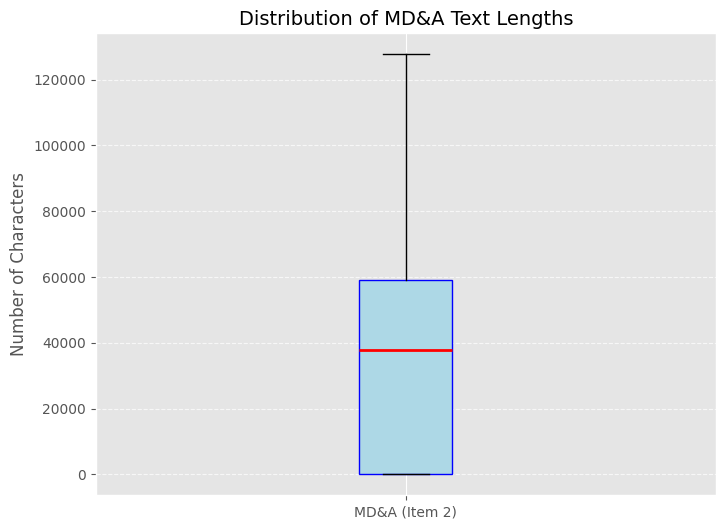

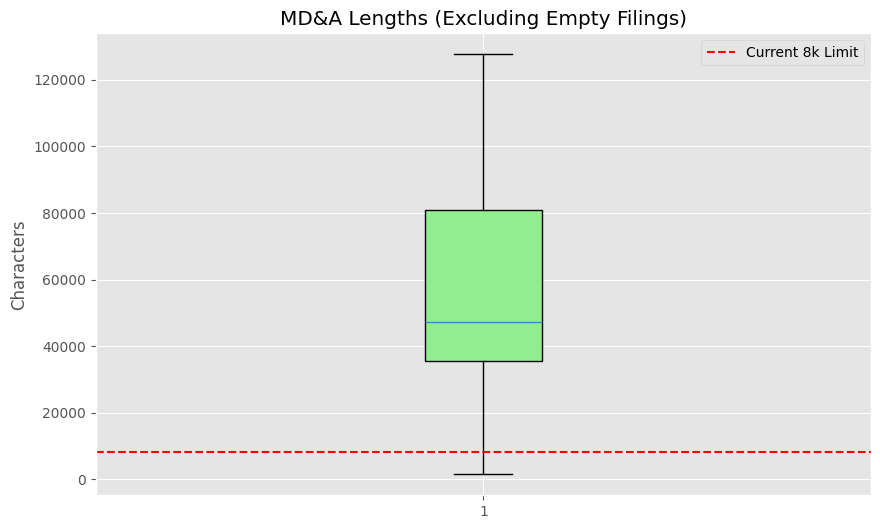

Removed 40 empty filings.
count       100.000000
mean      53920.150000
std       37494.656744
min        1450.000000
25%       35549.250000
50%       47128.500000
75%       80968.500000
max      127712.000000
Name: mda_text, dtype: float64
Summary Statistics for Text Lengths:
count       140.000000
mean      38514.392857
std       39986.252382
min           0.000000
25%           0.000000
50%       37901.500000
75%       58989.000000
max      127712.000000
Name: mda_text, dtype: float64


In [43]:
import matplotlib.pyplot as plt

# 1. Calculate lengths (char counts)
# Using features_df or df_clean_companies (the ones that still have 'mda_text')
text_lengths = df_clean_companies['mda_text'].str.len()

# 2. Create the Box Plot
plt.figure(figsize=(8, 6))
plt.boxplot(text_lengths, vert=True, patch_artist=True, 
            boxprops=dict(facecolor='lightblue', color='blue'),
            medianprops=dict(color='red', linewidth=2))

# 3. Add Labels and Title
plt.title('Distribution of MD&A Text Lengths', fontsize=14)
plt.ylabel('Number of Characters', fontsize=12)
plt.xticks([1], ['MD&A (Item 2)']) # Label for the x-axis tick

# Optional: Add grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
# 1. Create a filtered version with only actual text
df_real_text = df_clean_companies[df_clean_companies['mda_text'].str.len() > 0].copy()

# 2. Calculate lengths
real_lengths = df_real_text['mda_text'].str.len()

# 3. Plot with a horizontal line at your current 8,000 char limit
plt.figure(figsize=(10, 6))
plt.boxplot(real_lengths, vert=True, patch_artist=True, boxprops=dict(facecolor='lightgreen'))

# Draw the 'OpenAI Truncation' line
plt.axhline(y=8000, color='red', linestyle='--', label='Current 8k Limit')

plt.title('MD&A Lengths (Excluding Empty Filings)')
plt.ylabel('Characters')
plt.legend()
plt.show()

print(f"Removed {len(df_clean_companies) - len(df_real_text)} empty filings.")
print(real_lengths.describe())
plt.show()

# Print summary statistics for context
print("Summary Statistics for Text Lengths:")
print(text_lengths.describe())

In [44]:
# Count unique companies in the cleaned dataframe
remaining_count = df_real_text['ticker'].nunique()
remaining_tickers = df_real_text['ticker'].unique()

print(f"--- Final Dataset Summary ---")
print(f"Total Companies Remaining: {remaining_count}")
print(f"Total Filings Remaining:   {len(df_real_text)}")
print(f"Tickers: {', '.join(remaining_tickers)}")

# Check if any company has very few filings left
filings_per_company = df_real_text['ticker'].value_counts()
print("\nFilings per company:")
print(filings_per_company)

--- Final Dataset Summary ---
Total Companies Remaining: 5
Total Filings Remaining:   100
Tickers: MSFT, NVDA, BRK-B, LLY, AVGO

Filings per company:
ticker
MSFT     20
NVDA     20
BRK-B    20
LLY      20
AVGO     20
Name: count, dtype: int64


In [50]:
print(df_real_text.columns)
df_real_text.to_excel('companies_data_real_text.xlsx', index=False)

Index(['ticker', 'date', 'revenue', 'net_income', 'mda_text'], dtype='object')


In [51]:
from tqdm import tqdm
import pandas as pd

# 1. Create a working copy from your specific dataframe
features_df = df_real_text.copy()

sentiments = []

print(f"Analyzing sentiment for {len(features_df)} filings across {features_df['ticker'].nunique()} companies...")

# 2. Iterate through the flat 'mda_text' column
# Since the structure is flat, we just need one loop.
for text in tqdm(features_df['mda_text']):
    
    # Check if text exists and is long enough to be a valid MD&A
    if isinstance(text, str) and len(text) > 200:
        try:
            # --- Call your LLM function ---
            # Note: You might want to truncate text here if it's too long 
            # e.g., analysis = get_openai_sentiment(text[:15000])
            analysis = get_openai_sentiment(text)
            
            # Extract score (assuming your function returns a dict with 'score')
            sentiments.append(analysis['score'])
            
        except Exception as e:
            print(f"Error processing text: {e}")
            sentiments.append(0.0) # Fallback for errors
    else:
        sentiments.append(0.0) # Neutral for empty/short texts

# 3. Assign the new column
features_df['sentiment_score'] = sentiments

# 4. Create the final clean table by dropping the large text column
# We keep Ticker, Date, Revenue, Net_Income, and the new Sentiment Score
final_df = features_df.drop(columns=['mda_text'])

print("Analysis Complete.")
print(final_df.head())

Analyzing sentiment for 100 filings across 5 companies...


100%|██████████| 100/100 [01:32<00:00,  1.08it/s]

Analysis Complete.
   ticker        date       revenue    net_income  sentiment_score
20   MSFT  2026-01-28  8.127300e+10  3.845800e+10              0.2
21   MSFT  2025-10-29  7.767300e+10  2.774700e+10              0.2
22   MSFT  2025-04-30  7.006600e+10  2.582400e+10              0.2
23   MSFT  2025-01-29  6.963200e+10  2.410800e+10              0.2
24   MSFT  2024-10-30  6.558500e+10  2.466700e+10              0.2


In [ ]:
# Assuming you defined your list earlier:
tickers = ["AAPL", "MSFT", "NVDA", "GOOGL", "AMZN", "META", "TSLA", "BRK-B", "LLY", "AVGO"]

for ticker in tickers:
    print(f"\nFetching filings for {ticker}...")
    try:
        company = Company(ticker)
        filings = company.get_filings(form="10-Q")
        
        # Just print the first 2 rows to verify data exists without cluttering
        print(filings.to_pandas().head(2)[['form', 'filingDate', 'accessionNumber']])
        
    except Exception as e:
        print(f"❌ Could not fetch for {ticker}: {e}")


Fetching filings for AAPL...
❌ Could not fetch for AAPL: "['filingDate', 'accessionNumber'] not in index"

Fetching filings for MSFT...
❌ Could not fetch for MSFT: "['filingDate', 'accessionNumber'] not in index"

Fetching filings for NVDA...
❌ Could not fetch for NVDA: "['filingDate', 'accessionNumber'] not in index"

Fetching filings for GOOGL...
❌ Could not fetch for GOOGL: "['filingDate', 'accessionNumber'] not in index"

Fetching filings for AMZN...
❌ Could not fetch for AMZN: "['filingDate', 'accessionNumber'] not in index"

Fetching filings for META...
❌ Could not fetch for META: "['filingDate', 'accessionNumber'] not in index"

Fetching filings for TSLA...
❌ Could not fetch for TSLA: "['filingDate', 'accessionNumber'] not in index"

Fetching filings for BRK-B...
❌ Could not fetch for BRK-B: "['filingDate', 'accessionNumber'] not in index"

Fetching filings for LLY...
❌ Could not fetch for LLY: "['filingDate', 'accessionNumber'] not in index"

Fetching filings for AVGO...
❌ Cou

## 2. Step-by-Step Implementation Instructions
### Step 2: Data Extraction Function (The Feature Engine)

### Step 3: Market Data Alignment (The Target)

In [53]:
import yfinance as yf
import pandas as pd

# 1. Setup: Ensure dates are datetime objects
features_df['date'] = pd.to_datetime(features_df['date'])

# 2. Get the list of unique tickers and the date range
unique_tickers = features_df['ticker'].unique().tolist()
min_date = features_df['date'].min()
max_date = features_df['date'].max() + pd.DateOffset(days=120)

print(f"Downloading market data for {len(unique_tickers)} companies...")

# 3. Download data for each ticker and store in a dictionary
# This is safer than bulk download because it avoids MultiIndex confusion
market_data_dict = {}
for t in unique_tickers:
    # Download with a buffer to ensure we have data 90 days out
    df = yf.download(t, start=min_date, end=max_date, progress=False)
    
    # yfinance sometimes returns a MultiIndex column for 'Close' even for single tickers
    # We flattening it to be safe
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.droplevel(1) 
        
    market_data_dict[t] = df

# 4. Define the lookup function
def calculate_next_quarter_return(row):
    ticker = row['ticker']
    filing_date = row['date']
    
    # Retrieve the specific dataframe for this company
    if ticker not in market_data_dict or market_data_dict[ticker].empty:
        return None
        
    prices = market_data_dict[ticker]
    
    # --- Logic A: Get Entry Price (Filing Date) ---
    try:
        # Try exact match
        price_on_filing = prices.loc[filing_date.strftime('%Y-%m-%d')]['Close']
    except KeyError:
        # If weekend/holiday, take the NEXT available trading day
        future_mask = prices.index > filing_date
        if not future_mask.any(): return None
        price_on_filing = prices.loc[future_mask].iloc[0]['Close']

    # --- Logic B: Get Exit Price (90 Days Later) ---
    exit_date = filing_date + pd.DateOffset(days=90)
    
    try:
        # Try exact match
        price_in_90_days = prices.loc[exit_date.strftime('%Y-%m-%d')]['Close']
    except KeyError:
        # If weekend/holiday, take the NEXT available trading day
        future_mask = prices.index > exit_date
        if not future_mask.any(): return None
        price_in_90_days = prices.loc[future_mask].iloc[0]['Close']
        
    # --- Calculation ---
    # Ensure we are working with floats (sometimes yfinance returns Series)
    p_start = float(price_on_filing)
    p_end = float(price_in_90_days)
    
    return (p_end - p_start) / p_start

# 5. Apply the function
print("Calculating returns...")
features_df['next_quarter_return'] = features_df.apply(calculate_next_quarter_return, axis=1)

# Drop rows where we couldn't calculate return (e.g. data missing or too recent)
features_df.dropna(subset=['next_quarter_return'], inplace=True)

print("Calculation Complete.")
features_df.head()

Calculating returns...
Calculation Complete.


,ticker,date,revenue,net_income,mda_text,sentiment_score,next_quarter_return
21,MSFT,2025-10-29,7.767300e+10,2.774700e+10,ITEM 2. MANAGEMENT’S DISCUSSION AND ANALYSIS O...,0.2,-0.110923
22,MSFT,2025-04-30,7.006600e+10,2.582400e+10,ITEM 2. MANAGEMENT’S DISCUSSION AND ANALYSIS O...,0.2,0.299173
23,MSFT,2025-01-29,6.963200e+10,2.410800e+10,ITEM 2. MANAGEMENT’S DISCUSSION AND ANALYSIS O...,0.2,-0.107386
24,MSFT,2024-10-30,6.558500e+10,2.466700e+10,ITEM 2. MANAGEMENT’S DISCUSSION AND ANALYSIS O...,0.2,0.035986
25,MSFT,2024-04-25,6.185800e+10,2.193900e+10,ITEM 2. MANAGEMENT’S DISCUSSION AND ANALYSIS O...,0.2,0.076768


### Step 4: Feature Engineering

In [54]:
# 1. CRITICAL: Sort by Ticker and Date first
# This ensures that Quarter 1 is followed by Quarter 2 for the SAME company.
features_df = features_df.sort_values(by=['ticker', 'date'])

# 2. Apply calculations within each company group
features_df['revenue_growth'] = features_df.groupby('ticker')['revenue'].pct_change()
features_df['sentiment_change'] = features_df.groupby('ticker')['sentiment_score'].diff()

# 3. Net Margin is a row-by-row calculation (safe to do without grouping)
features_df['net_margin'] = features_df['net_income'] / features_df['revenue']

# 4. Remove the first row of each company (which will be NaN due to diff/pct_change)
features_df.dropna(inplace=True)

print("Feature Engineering Complete.")
print(features_df[['ticker', 'date', 'revenue_growth', 'sentiment_change']].head())

Feature Engineering Complete.
    ticker       date  revenue_growth  sentiment_change
198   AVGO 2019-09-13       -0.000363               0.0
197   AVGO 2020-03-13        0.062194               0.0
196   AVGO 2020-06-12       -0.019802              -0.1
195   AVGO 2020-09-11        0.013758               0.0
194   AVGO 2021-03-12        0.143274               0.0


### Step 5: Visualization (EDA)

Generating plots for 5 companies...


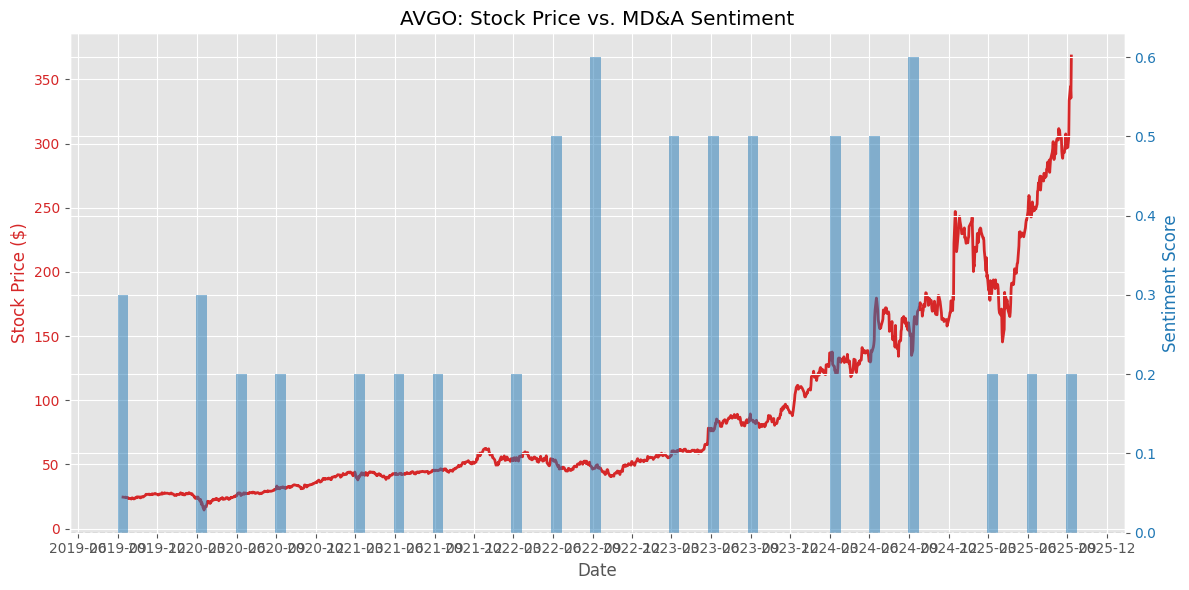

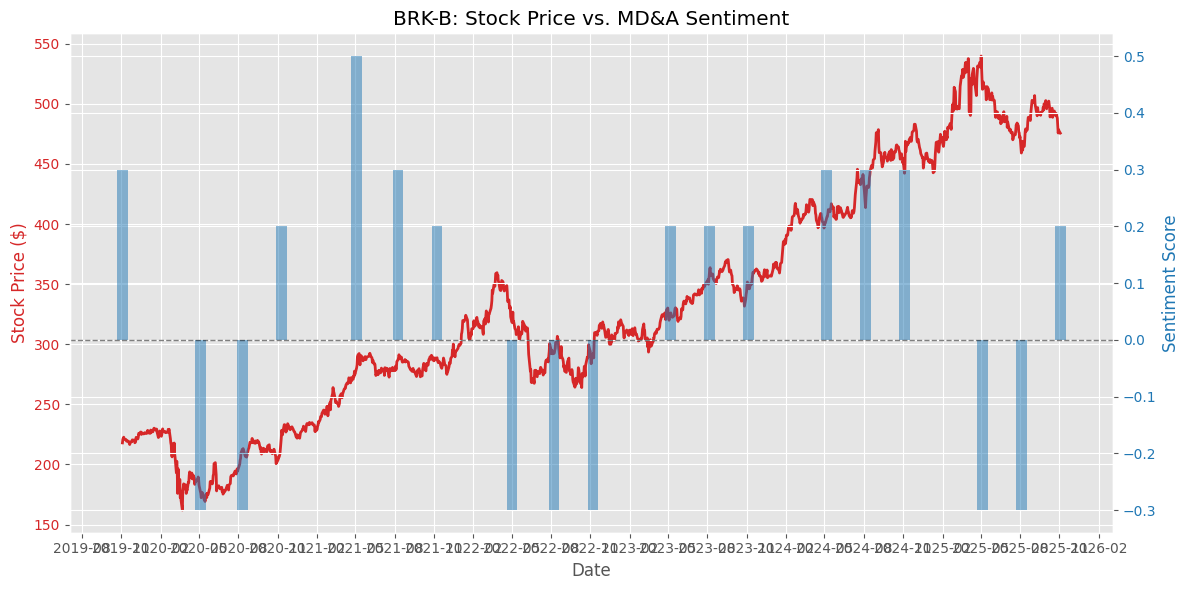

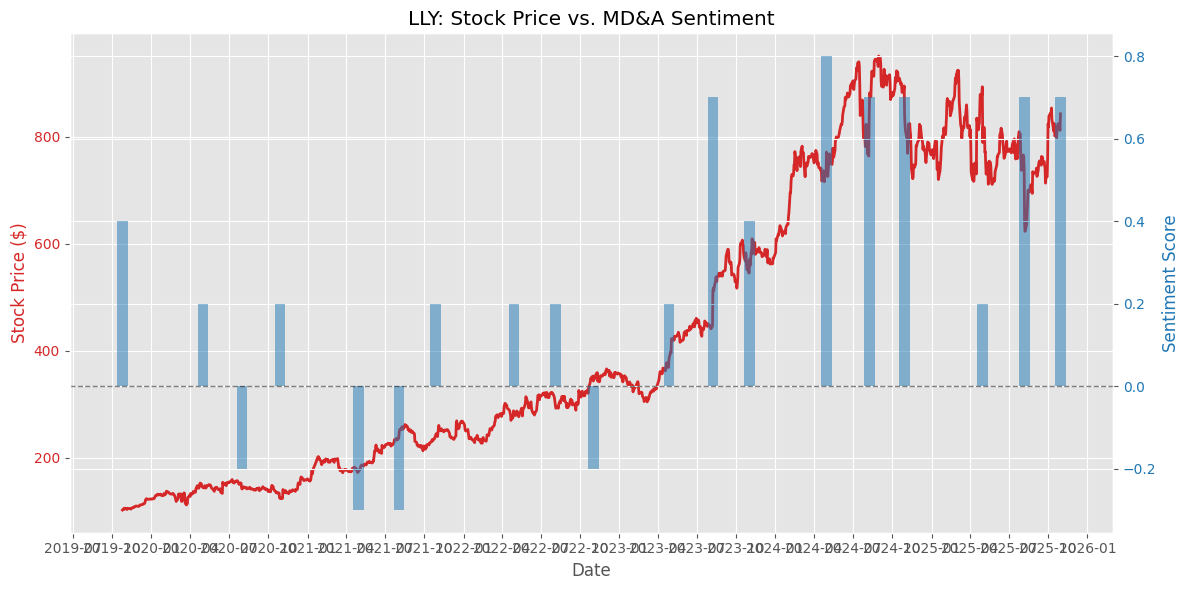

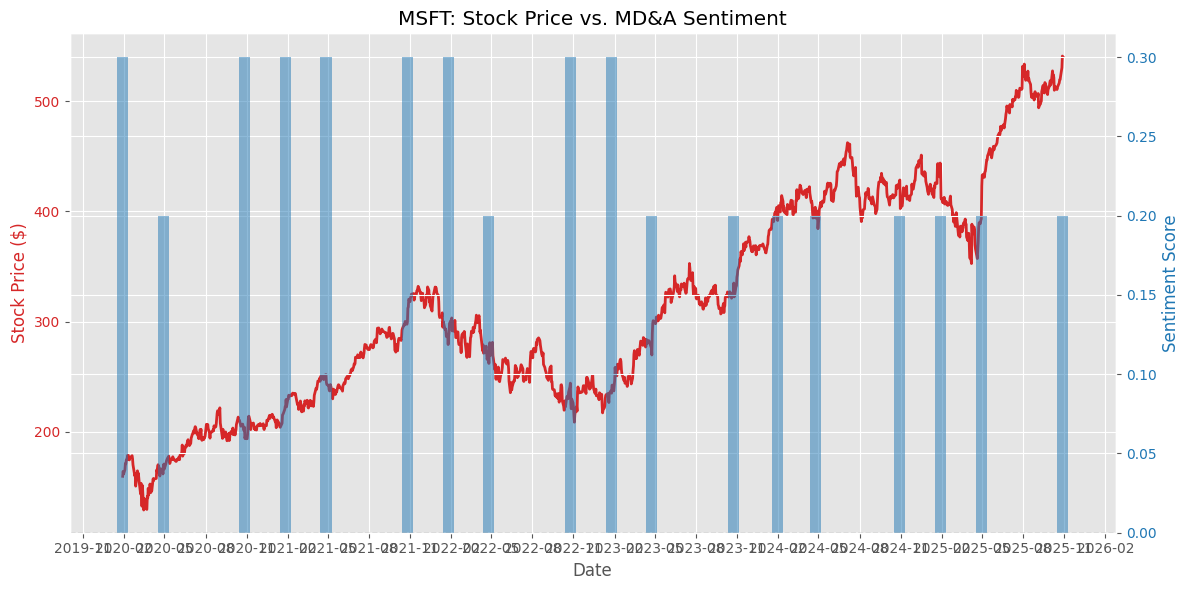

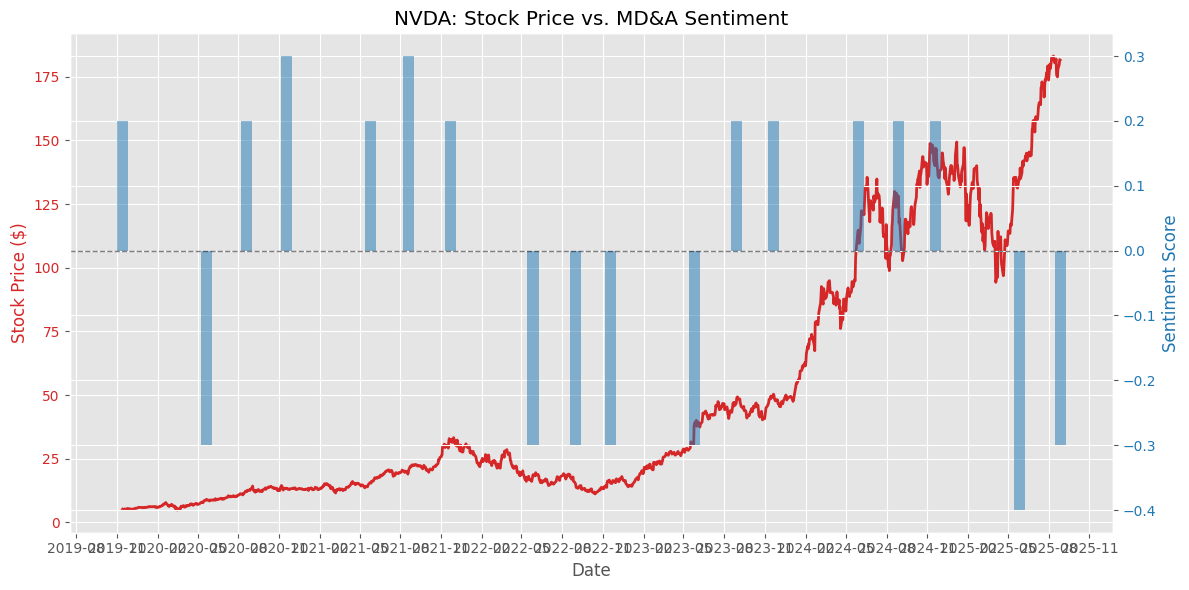

In [55]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Get list of unique companies present in the data
unique_tickers = features_df['ticker'].unique()

print(f"Generating plots for {len(unique_tickers)} companies...")

for ticker in unique_tickers:
    # 1. Filter data for the CURRENT company only
    company_df = features_df[features_df['ticker'] == ticker].sort_values('date')
    
    # Skip if no data for this company (safety check)
    if company_df.empty:
        continue

    # 2. Get the Market Data for this company
    # (Assuming you have 'market_data_dict' from the previous step)
    if ticker in market_data_dict:
        price_data = market_data_dict[ticker]
    else:
        print(f"Warning: No market data found for {ticker}")
        continue

    # --- Plotting ---
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # A. Plot Stock Price (Red Line)
    color = 'tab:red'
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Stock Price ($)', color=color)
    
    # We plot the full price history for context, limited to the range of our data
    min_date = company_df['date'].min()
    max_date = company_df['date'].max()
    
    # Slice the price data to match the sentiment period
    mask = (price_data.index >= min_date) & (price_data.index <= max_date)
    subset_prices = price_data.loc[mask]
    
    ax1.plot(subset_prices.index, subset_prices['Close'], color=color, linewidth=2, label='Stock Price')
    ax1.tick_params(axis='y', labelcolor=color)

    # B. Plot Sentiment (Blue Bars)
    ax2 = ax1.twinx()
    color = 'tab:blue'
    ax2.set_ylabel('Sentiment Score', color=color)
    
    # Width=20 works well for daily charts, adjust if bars are too thin/thick
    ax2.bar(company_df['date'], company_df['sentiment_score'], 
            color=color, alpha=0.5, width=25, label='Sentiment Score', zorder=2)
    
    ax2.tick_params(axis='y', labelcolor=color)
    
    # Zero line for sentiment
    ax2.axhline(0, color='black', lw=1, linestyle='--', alpha=0.5)

    # C. Formatting
    plt.title(f'{ticker}: Stock Price vs. MD&A Sentiment')
    
    # Optional: Format X-axis to show Years/Months clearly
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.xticks(rotation=45)
    
    fig.tight_layout()
    plt.show()

Rows with valid X and Y: 93


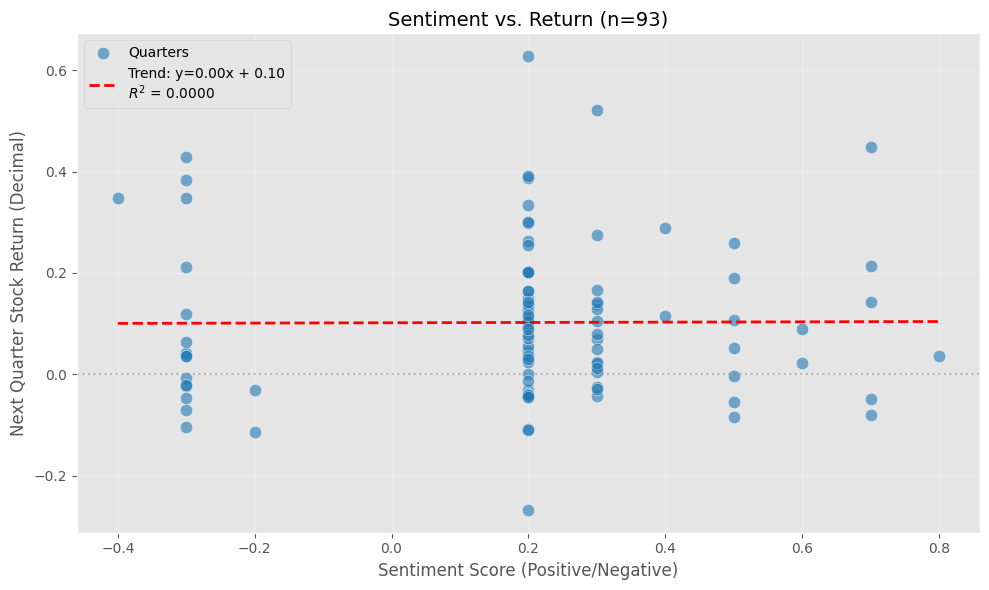

Correlation: 0.0055


In [56]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import pearsonr

# 1. Clean 'next_quarter_return'
# Handles cases where a cell might be a scalar, a Series, or None
def clean_val(val):
    if isinstance(val, pd.Series):
        return float(val.iloc[0]) if not val.empty else np.nan
    try:
        return float(val)
    except (ValueError, TypeError):
        return np.nan

# Apply the cleaning function
features_df['next_quarter_return_clean'] = features_df['next_quarter_return'].apply(clean_val)

# 2. Ensure sentiment is also clean float
features_df['sentiment_score'] = pd.to_numeric(features_df['sentiment_score'], errors='coerce')

# 3. Create the plotting dataframe (Drop NaNs)
plot_data = features_df[['sentiment_score', 'next_quarter_return_clean']].dropna()

print(f"Rows with valid X and Y: {len(plot_data)}")

if len(plot_data) > 2: # Need at least 2 points for a line, preferably more
    x = plot_data['sentiment_score']
    y = plot_data['next_quarter_return_clean']

    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Scatter plot
    ax.scatter(x, y, alpha=0.6, color='tab:blue', s=80, edgecolors='w', label='Quarters')

    # Calculate Trendline
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    
    # Calculate Statistics (Correlation and R-squared)
    correlation, _ = pearsonr(x, y)
    r_squared = correlation ** 2
    
    # Plot Trendline covering the full range
    x_range = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_range, p(x_range), "r--", linewidth=2, 
            label=f"Trend: y={z[0]:.2f}x + {z[1]:.2f}\n$R^2$ = {r_squared:.4f}")

    # Labels and Title
    ax.set_title(f'Sentiment vs. Return (n={len(plot_data)})', fontsize=14)
    ax.set_xlabel('Sentiment Score (Positive/Negative)', fontsize=12)
    ax.set_ylabel('Next Quarter Stock Return (Decimal)', fontsize=12)
    
    # Add a horizontal line at 0 return
    ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
    
    # Formatting
    ax.legend(loc='upper left', frameon=True)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

    print(f"Correlation: {correlation:.4f}")

else:
    print("Check failed. Not enough valid data points to plot.")
    # Debugging: show what the dirty data looks like if it failed
    if not features_df['next_quarter_return'].empty:
        print("Sample dirty value:", features_df['next_quarter_return'].iloc[0])
        print("Type:", type(features_df['next_quarter_return'].iloc[0]))


In [59]:
# 1. Sort by Ticker and Date to ensure correct order
features_df = features_df.sort_values(by=['ticker', 'date'])

# 2. Calculate Sentiment Change safely (Grouped by Ticker)
# This prevents the last quarter of Apple from affecting the first quarter of Amazon
features_df['sentiment_change'] = features_df.groupby('ticker')['sentiment_score'].diff()

# 3. Drop NaN values created by the diff() (First row of each company will be NaN)
features_df.dropna(subset=['sentiment_change', 'revenue_growth', 'next_quarter_return'], inplace=True)

print("Feature Engineering Complete. Added 'sentiment_change'.")
print(features_df[['ticker', 'date', 'sentiment_score', 'sentiment_change']].head())

Feature Engineering Complete. Added 'sentiment_change'.
    ticker       date  sentiment_score  sentiment_change
197   AVGO 2020-03-13              0.3               0.0
196   AVGO 2020-06-12              0.2              -0.1
195   AVGO 2020-09-11              0.2               0.0
194   AVGO 2021-03-12              0.2               0.0
193   AVGO 2021-06-11              0.2               0.0


### Step 6: Predictive Modeling

Training models for 5 companies using features: ['sentiment_score', 'sentiment_change', 'revenue_growth', 'net_margin']


🏢 Processing: AVGO
✅ MSE: 0.025297
Top Feature: net_margin (0.44)


C:\Users\honza\AppData\Local\Temp\ipykernel_2320\777028427.py:39: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X_clean = X.applymap(clean_val)


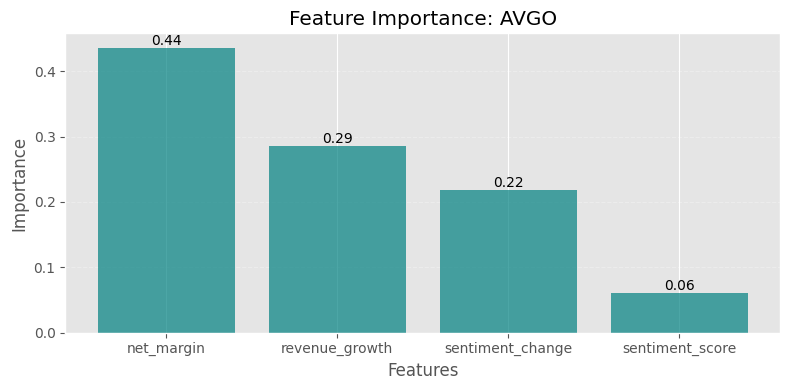


🏢 Processing: BRK-B


C:\Users\honza\AppData\Local\Temp\ipykernel_2320\777028427.py:39: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X_clean = X.applymap(clean_val)


✅ MSE: 0.002752
Top Feature: sentiment_change (0.31)


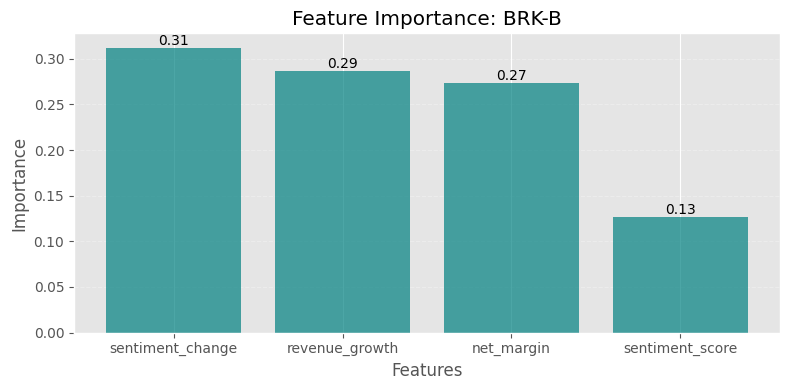


🏢 Processing: LLY


C:\Users\honza\AppData\Local\Temp\ipykernel_2320\777028427.py:39: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X_clean = X.applymap(clean_val)


✅ MSE: 0.055837
Top Feature: net_margin (0.57)


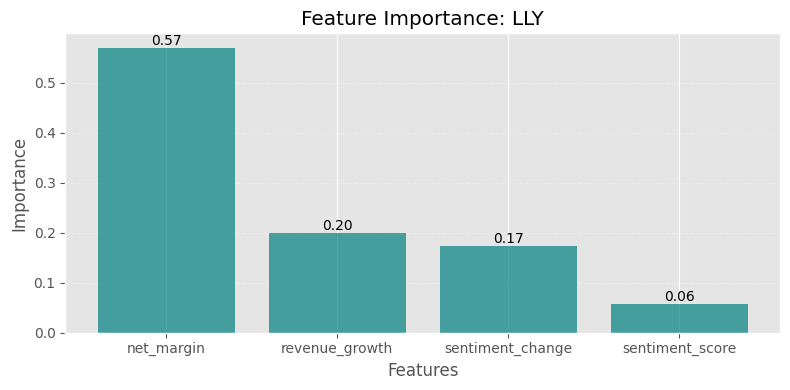


🏢 Processing: MSFT


C:\Users\honza\AppData\Local\Temp\ipykernel_2320\777028427.py:39: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X_clean = X.applymap(clean_val)


✅ MSE: 0.028808
Top Feature: net_margin (0.47)


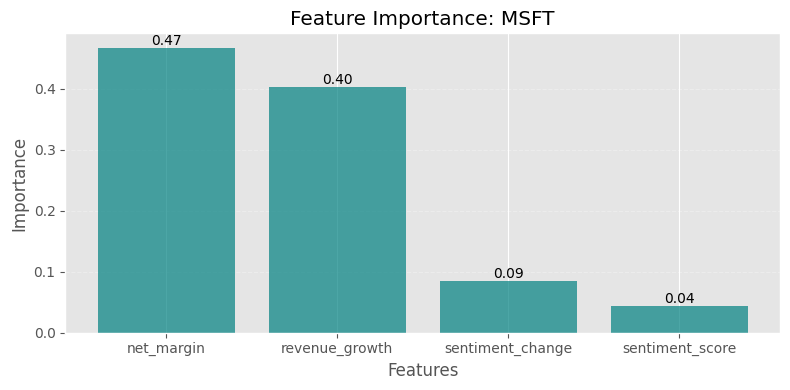


🏢 Processing: NVDA


C:\Users\honza\AppData\Local\Temp\ipykernel_2320\777028427.py:39: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X_clean = X.applymap(clean_val)


✅ MSE: 0.061108
Top Feature: revenue_growth (0.44)


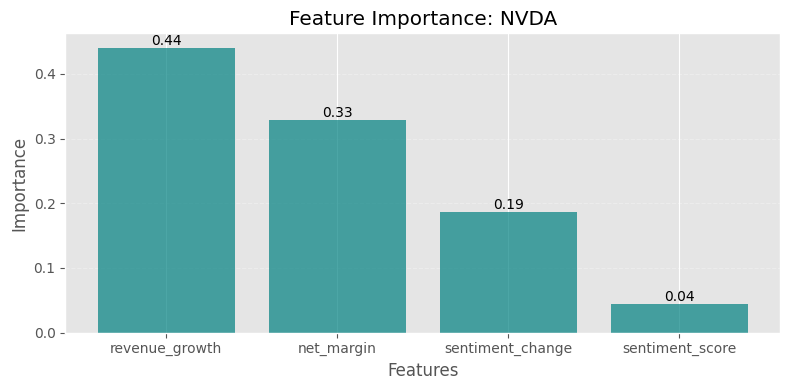

In [60]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Updated Feature List
features = ['sentiment_score', 'sentiment_change', 'revenue_growth', 'net_margin']
target = 'next_quarter_return'

tickers = features_df['ticker'].unique()
company_models = {}

print(f"Training models for {len(tickers)} companies using features: {features}\n")

for ticker in tickers:
    print(f"\n{'='*40}")
    print(f"🏢 Processing: {ticker}")
    
    # --- A. Filter Data ---
    df_company = features_df[features_df['ticker'] == ticker].sort_values('date').copy()
    
    # Check for minimum data points (Need at least 6-8 quarters for a split)
    if len(df_company) < 8:
        print(f"⚠️ Skipping {ticker}: Not enough data ({len(df_company)} rows)")
        continue

    # --- B. Clean & Prepare Data ---
    X = df_company[features]
    y = df_company[target]

    # Helper to clean individual cells
    def clean_val(val):
        if isinstance(val, pd.Series):
            val = val.iloc[0]
        return pd.to_numeric(val, errors='coerce')

    # Apply cleaning
    X_clean = X.applymap(clean_val)
    y_clean = y.apply(clean_val)
    
    # Combine to drop NaNs
    combined = pd.concat([X_clean, y_clean], axis=1).dropna()
    
    if combined.empty:
        print("⚠️ No valid data after cleaning.")
        continue

    X_final = combined[features]
    y_final = combined[target]

    # --- C. Time-Based Split (80/20) ---
    train_size = int(len(X_final) * 0.8)
    X_train, X_test = X_final.iloc[:train_size], X_final.iloc[train_size:]
    y_train, y_test = y_final.iloc[:train_size], y_final.iloc[train_size:]

    if len(X_test) == 0:
        print("⚠️ Not enough data for testing.")
        continue

    # --- D. Train Model ---
    model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=5)
    model.fit(X_train, y_train)
    company_models[ticker] = model

    # --- E. Evaluate ---
    predictions = model.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    print(f'✅ MSE: {mse:.6f}')

    # --- F. Feature Importance Plot ---
    importances = model.feature_importances_
    fi_df = pd.DataFrame({'feature': features, 'importance': importances})
    fi_df = fi_df.sort_values('importance', ascending=False)
    
    print(f"Top Feature: {fi_df.iloc[0]['feature']} ({fi_df.iloc[0]['importance']:.2f})")

    plt.figure(figsize=(8, 4))
    bars = plt.bar(fi_df['feature'], fi_df['importance'], color='teal', alpha=0.7)
    plt.title(f'Feature Importance: {ticker}')
    plt.xlabel('Features')
    plt.ylabel('Importance')
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    
    # Label bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.2f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

### Step 7: Evaluation & Conclusion

In [27]:
# The index of X_test contains the filing dates for the quarters being predicted
print("The model is predicting returns for the quarters following these filing dates:")
print(X_test.index)

# To see the actual predicted values vs truth
y_pred = model.predict(X_test)
comparison = pd.DataFrame({
    'Filing Date': X_test.index,
    'Actual Next Q Return': y_test.values,
    'Predicted Next Q Return': y_pred
})
display(comparison)

The model is predicting returns for the quarters following these filing dates:
Index([16, 17, 18, 19], dtype='int64')


,Filing Date,Actual Next Q Return,Predicted Next Q Return
0,16,0.106090,0.282782
1,17,0.383896,0.256258
2,18,0.300067,-0.005352
3,19,0.403350,0.225419



📈 EVALUATION REPORT: AVGO
Most Recent Predictions:


C:\Users\honza\AppData\Local\Temp\ipykernel_2320\2200332449.py:28: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X = df_company[features].applymap(clean_val)


,Actual Return,Predicted Return,Difference
date,,,
2025-03-12,0.263297,0.096823,0.166474
2025-06-11,0.334318,0.073917,0.260401
2025-09-10,0.101242,0.044572,0.056670


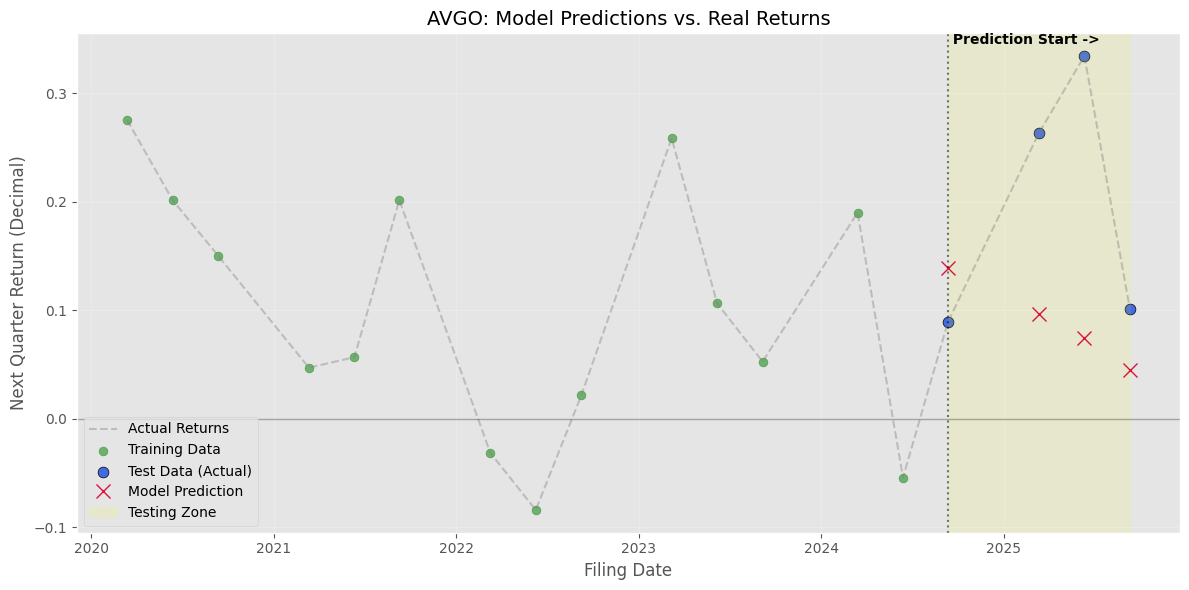


📈 EVALUATION REPORT: BRK-B
Most Recent Predictions:


C:\Users\honza\AppData\Local\Temp\ipykernel_2320\2200332449.py:28: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X = df_company[features].applymap(clean_val)


,Actual Return,Predicted Return,Difference
date,,,
2025-05-05,-0.103563,-0.003260,-0.100304
2025-08-04,0.036092,0.037954,-0.001862
2025-11-03,0.024407,0.054964,-0.030557


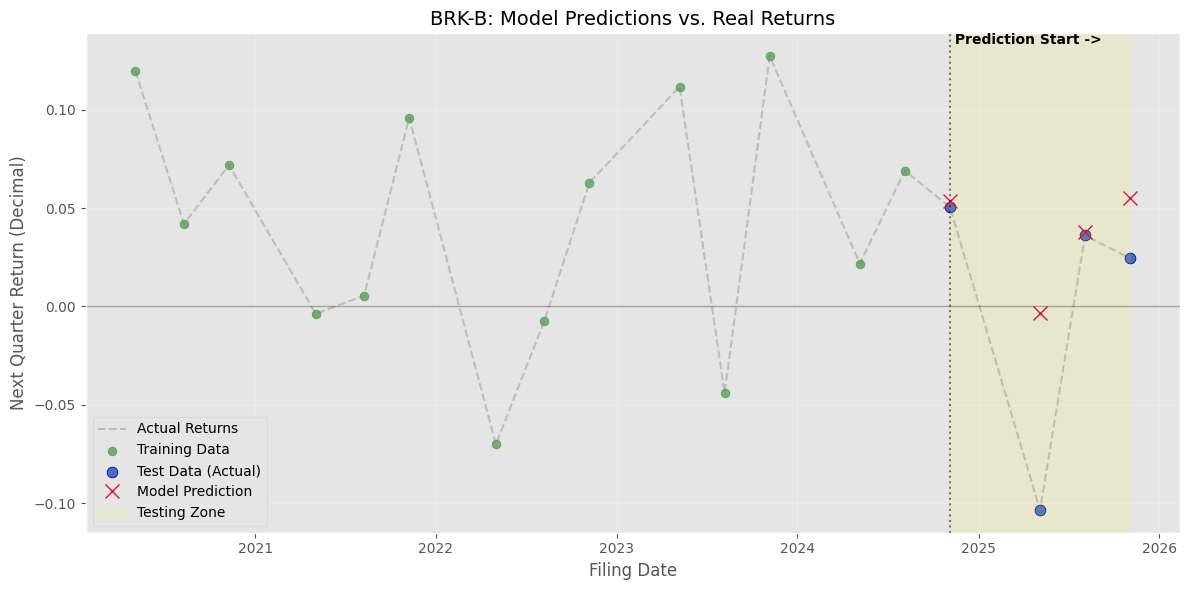


📈 EVALUATION REPORT: LLY
Most Recent Predictions:


C:\Users\honza\AppData\Local\Temp\ipykernel_2320\2200332449.py:28: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X = df_company[features].applymap(clean_val)


,Actual Return,Predicted Return,Difference
date,,,
2025-05-01,-0.040879,0.077193,-0.118072
2025-08-07,0.447810,0.064924,0.382886
2025-10-30,0.214095,0.038661,0.175435


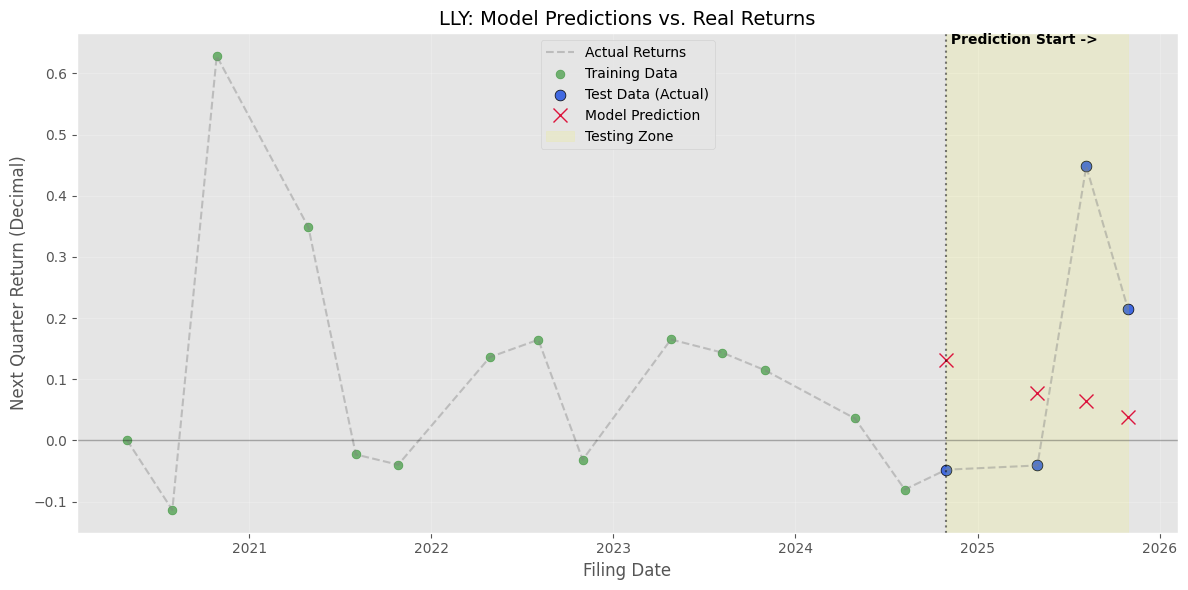


📈 EVALUATION REPORT: MSFT
Most Recent Predictions:


C:\Users\honza\AppData\Local\Temp\ipykernel_2320\2200332449.py:28: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X = df_company[features].applymap(clean_val)


,Actual Return,Predicted Return,Difference
date,,,
2025-01-29,-0.107386,0.124294,-0.231679
2025-04-30,0.299173,0.116419,0.182754
2025-10-29,-0.110923,0.039328,-0.150251


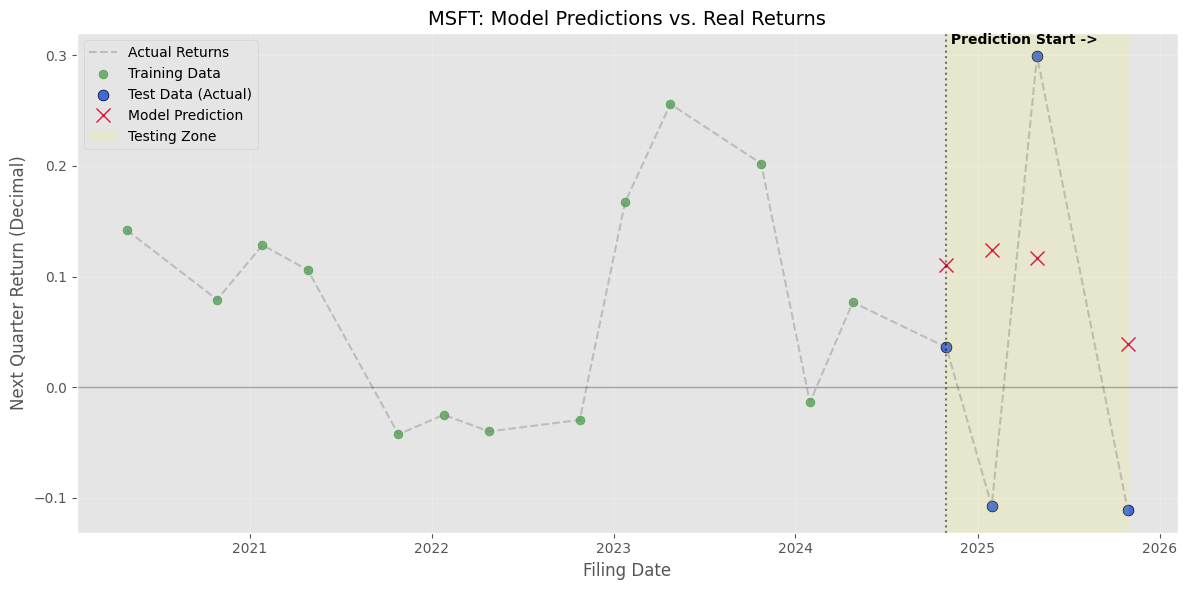


📈 EVALUATION REPORT: NVDA
Most Recent Predictions:


C:\Users\honza\AppData\Local\Temp\ipykernel_2320\2200332449.py:28: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X = df_company[features].applymap(clean_val)


,Actual Return,Predicted Return,Difference
date,,,
2024-11-20,-0.044420,0.260860,-0.305280
2025-05-28,0.348436,0.155342,0.193094
2025-08-27,-0.020760,0.241942,-0.262702


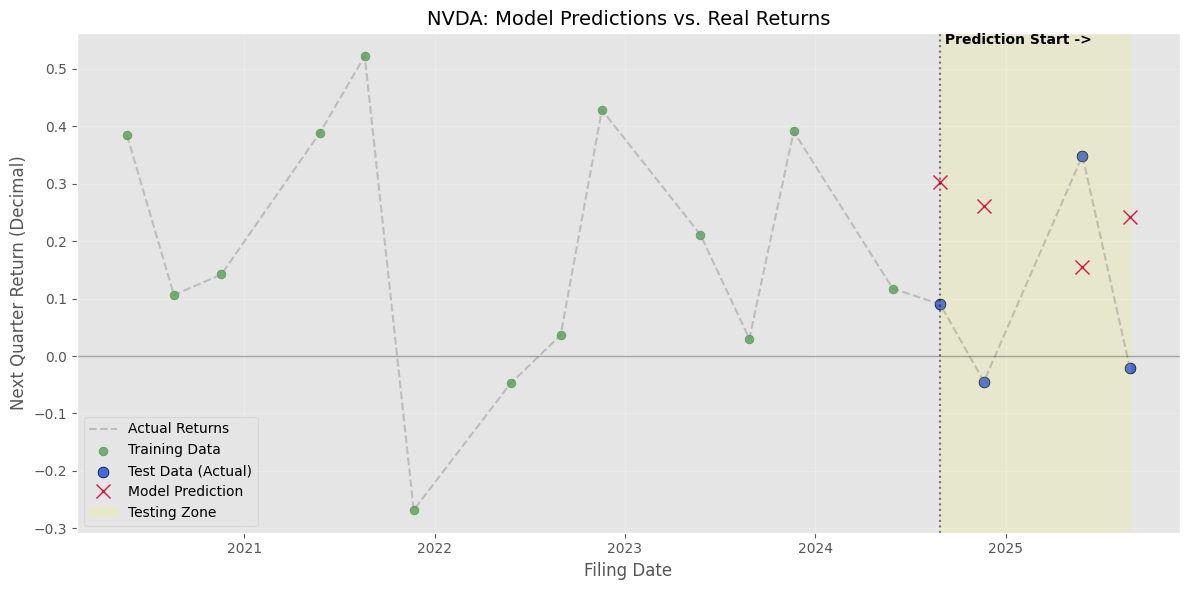

In [62]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Loop through every company we have a model for
for ticker, model in company_models.items():
    
    print(f"\n{'='*50}")
    print(f"📈 EVALUATION REPORT: {ticker}")
    print(f"{'='*50}")
    
    # --- 1. Reconstruct the Data for this Company ---
    # We must redo the filtering to get the correct Train/Test sets for *this* ticker
    df_company = features_df[features_df['ticker'] == ticker].sort_values('date').copy()
    
    # CRITICAL: Set date as index so the plots show dates, not row numbers
    df_company.set_index('date', inplace=True)
    
    # Define features and target
    features = ['sentiment_score', 'sentiment_change', 'revenue_growth', 'net_margin']
    target = 'next_quarter_return'

    # Cleaning helper (same as before)
    def clean_val(val):
        if isinstance(val, pd.Series): val = val.iloc[0]
        return pd.to_numeric(val, errors='coerce')

    X = df_company[features].applymap(clean_val)
    y = df_company[target].apply(clean_val)
    
    # Drop NaNs
    combined = pd.concat([X, y], axis=1).dropna()
    
    if combined.empty or len(combined) < 8:
        print(f"Skipping {ticker} (insufficient data)")
        continue
        
    X_final = combined[features]
    y_final = combined[target]

    # Time-based Split
    train_size = int(len(X_final) * 0.8)
    X_train, X_test = X_final.iloc[:train_size], X_final.iloc[train_size:]
    y_train, y_test = y_final.iloc[:train_size], y_final.iloc[train_size:]
    
    if X_test.empty:
        print(f"Skipping {ticker} (no test data)")
        continue

    # --- 2. Make Predictions ---
    y_pred = model.predict(X_test)
    
    # Create comparison table
    comparison = pd.DataFrame({
        'Actual Return': y_test,
        'Predicted Return': y_pred,
        'Difference': y_test - y_pred
    })
    
    print("Most Recent Predictions:")
    display(comparison.tail(3))

    # --- 3. Plotting (Your Code Adapted) ---
    
    # Prepare full timeline
    y_actual_full = pd.concat([y_train, y_test]).sort_index()
    y_pred_series = pd.Series(y_pred, index=X_test.index)
    
    plt.figure(figsize=(12, 6))

    # Plot Actual Returns (Full History)
    plt.plot(y_actual_full.index, y_actual_full, label='Actual Returns', 
             color='gray', alpha=0.4, linewidth=1.5, linestyle='--')

    # Highlight Training Data
    plt.scatter(y_train.index, y_train, color='forestgreen', label='Training Data', s=40, alpha=0.6)

    # Highlight Test Data (Actual)
    plt.scatter(y_test.index, y_test, color='royalblue', label='Test Data (Actual)', s=60, edgecolors='black')

    # Plot Model Predictions
    plt.plot(y_pred_series.index, y_pred_series, color='crimson', label='Model Prediction', 
             marker='x', markersize=10, linewidth=2, linestyle='None') # 'None' prevents connecting predictions with lines

    # Visual cues for the split
    if not X_test.empty:
        split_date = X_test.index.min()
        plt.axvline(x=split_date, color='black', linestyle=':', alpha=0.5)
        plt.text(split_date, plt.ylim()[1], ' Prediction Start ->', verticalalignment='top', fontsize=10, fontweight='bold')
        
        # Shade the testing zone
        plt.axvspan(split_date, y_actual_full.index.max(), color='yellow', alpha=0.1, label='Testing Zone')

    # Formatting
    plt.title(f'{ticker}: Model Predictions vs. Real Returns', fontsize=14)
    plt.xlabel('Filing Date')
    plt.ylabel('Next Quarter Return (Decimal)')
    plt.axhline(0, color='black', lw=1, alpha=0.3)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()



Starting Robust Walk-Forward (Purging Overlaps)...


C:\Users\honza\AppData\Local\Temp\ipykernel_2320\1398439252.py:68: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X_train_all = train_df[features].applymap(lambda x: pd.to_numeric(x, errors='coerce')).fillna(0)
C:\Users\honza\AppData\Local\Temp\ipykernel_2320\1398439252.py:78: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X_test = ticker_test[features].applymap(lambda x: pd.to_numeric(x, errors='coerce')).fillna(0)
C:\Users\honza\AppData\Local\Temp\ipykernel_2320\1398439252.py:78: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X_test = ticker_test[features].applymap(lambda x: pd.to_numeric(x, errors='coerce')).fillna(0)
C:\Users\honza\AppData\Local\Temp\ipykernel_2320\1398439252.py:68: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X_train_all = train_df[features].applymap(lambda x: pd.to_numeric(x, errors='coerce')).fillna(0)
C:\Users\hon

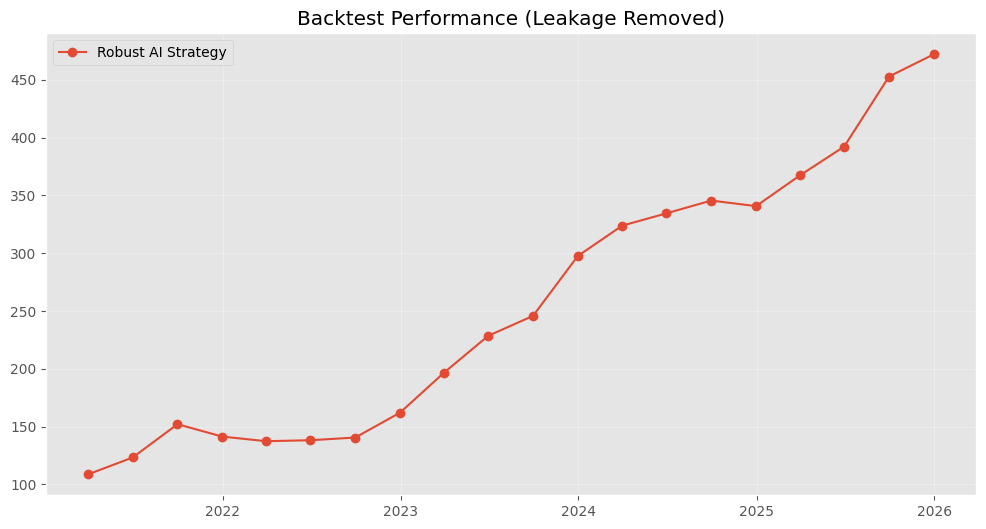

         date         selection  portfolio_value
15 2024-12-31  NVDA, LLY, BRK-B       340.667756
16 2025-03-31        MSFT, AVGO       367.224796
17 2025-06-30  NVDA, BRK-B, LLY       392.195262
18 2025-09-30  LLY, BRK-B, NVDA       452.742612
19 2025-12-31  BRK-B, MSFT, LLY       471.996120


In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.ensemble import RandomForestRegressor

# --- Configuration ---
start_year = 2021
initial_capital = 100.0
top_n = 3
lookahead_days = 90  # The duration of your trade target

# 1. Prepare Data
features_df['date'] = pd.to_datetime(features_df['date'])
features_df['quarter'] = features_df['date'].dt.to_period('Q')
features_df = features_df.sort_values('date')

all_quarters = sorted(features_df['quarter'].unique())
trading_quarters = [q for q in all_quarters if q.year >= start_year]

portfolio_history = []
portfolio_value = initial_capital

print(f"Starting Robust Walk-Forward (Purging Overlaps)...")

for current_q in trading_quarters:
    
    # --- 1. Identify the Prediction Date ---
    # We need to know WHEN we are making this decision. 
    # Usually, it's the earliest filing date in the current quarter.
    test_df = features_df[features_df['quarter'] == current_q].copy()
    if test_df.empty: continue
    
    # The moment we start trading this quarter
    decision_date = test_df['date'].min()
    
    # --- 2. Define Training Set with SAFETY GAP ---
    # Standard split: everything before this quarter
    potential_train_df = features_df[features_df['quarter'] < current_q].copy()
    
    # CRITICAL FIX: Purge any training rows where the trade hasn't finished yet
    # We only keep rows where (Filing_Date + 90 Days) < Decision_Date
    valid_mask = (potential_train_df['date'] + pd.Timedelta(days=lookahead_days)) < decision_date
    train_df = potential_train_df[valid_mask].copy()
    
    # Debug: Check how many rows were dropped due to leakage
    # dropped_count = len(potential_train_df) - len(train_df)
    # if dropped_count > 0: print(f"[{current_q}] Purged {dropped_count} overlapping rows to prevent leakage.")

    if train_df.empty or len(train_df) < 10: 
        print(f"Skipping {current_q}: Not enough historical closed trades.")
        continue

    # --- 3. Training & Prediction (Standard) ---
    predictions = []
    tickers_in_quarter = test_df['ticker'].unique()
    
    # Define features
    features = ['sentiment_score', 'sentiment_change', 'revenue_growth', 'net_margin']
    target = 'next_quarter_return'

    # Train one global model or per-ticker model? 
    # Global is often more stable for small datasets, but let's stick to your per-ticker logic 
    # or better: use a Global Model if per-ticker data is too sparse after purging.
    
    # Let's use a simple Global Model here for robustness on small data
    # (Mixing all companies helps the model learn general sentiment patterns)
    X_train_all = train_df[features].applymap(lambda x: pd.to_numeric(x, errors='coerce')).fillna(0)
    y_train_all = train_df[target].apply(lambda x: pd.to_numeric(x, errors='coerce')).fillna(0)
    
    model = RandomForestRegressor(n_estimators=50, max_depth=3, random_state=42)
    model.fit(X_train_all, y_train_all)
    
    for ticker in tickers_in_quarter:
        ticker_test = test_df[test_df['ticker'] == ticker]
        if ticker_test.empty: continue
        
        X_test = ticker_test[features].applymap(lambda x: pd.to_numeric(x, errors='coerce')).fillna(0)
        
        # Predict
        pred_return = model.predict(X_test)[0]
        actual_return = ticker_test[target].iloc[0]
        
        predictions.append({
            'ticker': ticker,
            'pred_return': pred_return,
            'actual_return': actual_return
        })

    # --- 4. Portfolio Construction ---
    if not predictions:
        period_return = 0.0
        selection = "CASH"
    else:
        pred_df = pd.DataFrame(predictions)
        # Select Top N with positive signal
        top_picks = pred_df[pred_df['pred_return'] > 0.0].nlargest(top_n, 'pred_return')
        
        if top_picks.empty:
            period_return = 0.0
            selection = "CASH (Bearish)"
        else:
            period_return = top_picks['actual_return'].mean()
            selection = ", ".join(top_picks['ticker'].tolist())

    portfolio_value = portfolio_value * (1 + period_return)
    
    q_end_date = current_q.end_time.date()
    portfolio_history.append({
        'date': pd.to_datetime(q_end_date),
        'portfolio_value': portfolio_value,
        'selection': selection,
        'return': period_return
    })

# --- Plotting ---
df_perf = pd.DataFrame(portfolio_history)
if not df_perf.empty:
    plt.figure(figsize=(12, 6))
    plt.plot(df_perf['date'], df_perf['portfolio_value'], marker='o', label='Robust AI Strategy')
    plt.title("Backtest Performance (Leakage Removed)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
    
    print(df_perf[['date', 'selection', 'portfolio_value']].tail())
else:
    print("No trades made.")

In [81]:
print(df_perf['portfolio_value'])

0     108.763518
1     123.305892
2     152.092611
3     141.358907
4     137.367060
5     138.212938
6     140.534308
7     162.060403
8     196.542090
9     228.504528
10    245.733096
11    297.554220
12    323.758015
13    334.444211
14    345.480147
15    340.667756
16    367.224796
17    392.195262
18    452.742612
19    471.996120
Name: portfolio_value, dtype: float64
